# Next-Word Prediction: Model Comparison

Compares **SimpleRNN**, **LSTM** and **GRU** on the same data, the same split, the same hyperparameters and the same seed. Only the recurrent layer changes, so any difference is down to the architecture.

`03_lstm.ipynb` and `04_gru.ipynb` must be run first. Any model missing from `outputs/metrics.json` is trained here (set `TRAIN_MISSING = False` to skip that).

## 1. Setup

In [1]:
%matplotlib inline
import os
import sys
sys.path.append(os.path.abspath(".."))  # so `import config` and `from src...` work from notebooks/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import config
from src.dataset import load_corpus, prepare_data
from src.preprocess import Vocabulary, clean_text, split_sentences, tokenize

np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("TensorFlow:", tf.__version__)
print(f"Epochs={config.EPOCHS}  Units={config.UNITS}  EmbedDim={config.EMBED_DIM}  BatchSize={config.BATCH_SIZE}  SeqLen={config.SEQ_LEN}")
print("Corpus:", config.DEFAULT_CORPUS)
print("Outputs:", config.OUTPUTS_DIR)

TensorFlow: 2.21.0
Epochs=8  Units=64  EmbedDim=64  BatchSize=256  SeqLen=5
Corpus: C:\Users\User\Downloads\next-word-prediction (3)\next-word-prediction-main\data\raw\corpus.txt
Outputs: C:\Users\User\Downloads\next-word-prediction (3)\next-word-prediction-main\outputs


In [2]:
TRAIN_MISSING = True  # train any model that has no results yet (SimpleRNN is trained here if needed)

## 2. Collect results

In [3]:
from src.train import train

metrics_path = config.OUTPUTS_DIR / "metrics.json"
metrics = json.loads(metrics_path.read_text()) if metrics_path.exists() else {}

for kind in config.MODEL_KINDS:
    if kind not in metrics and TRAIN_MISSING:
        print(f"--- training missing model: {kind}")
        train(
            kind,
            config.DEFAULT_CORPUS,
            verbose=2,
        )
        metrics = json.loads(metrics_path.read_text())

labels = {"rnn": "SimpleRNN", "lstm": "LSTM", "gru": "GRU"}
df = pd.DataFrame(metrics).T.loc[[k for k in config.MODEL_KINDS if k in metrics]]
df = df[["parameters", "top1_accuracy", "top5_accuracy", "perplexity", "test_loss", "train_seconds", "epochs_run", "best_epoch"]]
df.index = [labels[k] for k in df.index]
df

--- training missing model: rnn
Data: {"vocab_size": 10000, "train_samples": 976755, "val_samples": 120778, "test_samples": 121282, "seq_len": 5}


Model: "next_word_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_dropout (Dropout)         │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_word_probs (Dense)         │ (None, 10000)          │       650,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,298,256 (4.95 MB)

 Trainable params: 1,298,256 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
3816/3816 - 161s - 42ms/step - loss: 6.4067 - top1_accuracy: 0.1055 - top5_accuracy: 0.2478 - val_loss: 5.9403 - val_top1_accuracy: 0.1360 - val_top5_accuracy: 0.2896 - learning_rate: 0.0010
Epoch 2/8
3816/3816 - 215s - 56ms/step - loss: 6.0025 - top1_accuracy: 0.1292 - top5_accuracy: 0.2839 - val_loss: 5.7840 - val_top1_accuracy: 0.1449 - val_top5_accuracy: 0.3064 - learning_rate: 0.0010
Epoch 3/8
3816/3816 - 230s - 60ms/step - loss: 5.8864 - top1_accuracy: 0.1355 - top5_accuracy: 0.2942 - val_loss: 5.7114 - val_top1_accuracy: 0.1504 - val_top5_accuracy: 0.3145 - learning_rate: 0.0010
Epoch 4/8
3816/3816 - 213s - 56ms/step - loss: 5.8183 - top1_accuracy: 0.1398 - top5_accuracy: 0.3005 - val_loss: 5.6666 - val_top1_accuracy: 0.1531 - val_top5_accuracy: 0.3192 - learning_rate: 0.0010
Epoch 5/8
3816/3816 - 178s - 47ms/step - loss: 5.7668 - top1_accuracy: 0.1421 - top5_accuracy: 0.3051 - val_loss: 5.6349 - val_top1_accuracy: 0.1550 - val_top5_accuracy: 0.3225 - learning_rate: 0.

,parameters,top1_accuracy,top5_accuracy,perplexity,test_loss,train_seconds,epochs_run,best_epoch
SimpleRNN,1298256,0.1577,0.3302,262.11,5.5688,1524.8,8,8
LSTM,1323024,0.1574,0.3281,265.92,5.5832,1388.6,8,8
GRU,1314960,0.1601,0.3337,253.01,5.5334,1535.6,8,8


## 3. Comparison table

In [4]:
def md_table(frame):
    header = ["Model", "Parameters", "Top-1 accuracy", "Top-5 accuracy", "Perplexity", "Training time"]
    lines = ["| " + " | ".join(header) + " |", "|" + "|".join(["---"] * len(header)) + "|"]
    for name, r in frame.sort_values("perplexity").iterrows():
        minutes, seconds = divmod(int(r.train_seconds), 60)
        time_str = f"{minutes}m {seconds:02d}s"
        lines.append(
            f"| {name} | {int(r.parameters):,} | {r.top1_accuracy:.2%} | "
            f"{r.top5_accuracy:.2%} | {r.perplexity:.2f} | {time_str} |"
        )
    return "\n".join(lines)

table = md_table(df)
(config.OUTPUTS_DIR / "results.md").write_text(table + "\n", encoding="utf-8")
print(table)
print("\nSaved to outputs/results.md: paste this table into the README.")

| Model | Parameters | Top-1 accuracy | Top-5 accuracy | Perplexity | Training time |
|---|---|---|---|---|---|
| GRU | 1,314,960 | 16.01% | 33.37% | 253.01 | 25m 35s |
| SimpleRNN | 1,298,256 | 15.77% | 33.02% | 262.11 | 25m 24s |
| LSTM | 1,323,024 | 15.74% | 32.81% | 265.92 | 23m 08s |

Saved to outputs/results.md: paste this table into the README.


## 4. Charts

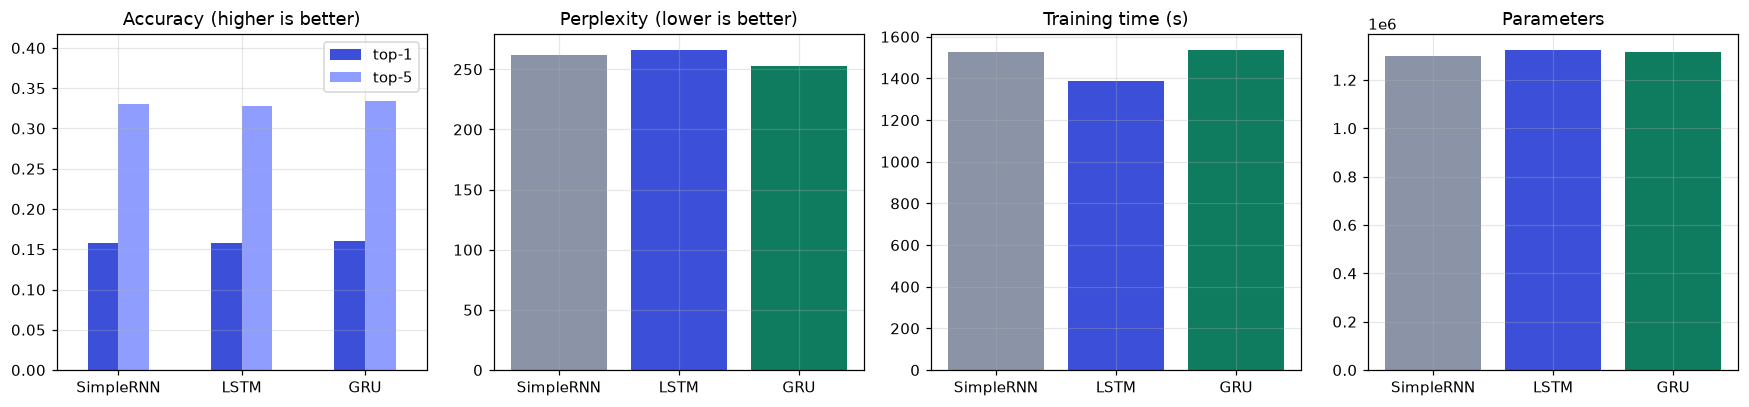

In [5]:
%matplotlib inline
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
colors = ["#8a94a6", "#3b4fd8", "#0f7b5f"][: len(df)]

acc = df[["top1_accuracy", "top5_accuracy"]]
acc.plot.bar(ax=axes[0], rot=0, color=["#3b4fd8", "#8f9dff"])
axes[0].set(title="Accuracy (higher is better)", ylim=(0, min(1, acc.values.max() * 1.25)))
axes[0].legend(["top-1", "top-5"])

for ax, col, title in zip(axes[1:], ["perplexity", "train_seconds", "parameters"],
                          ["Perplexity (lower is better)", "Training time (s)", "Parameters"]):
    ax.bar(df.index, df[col], color=colors)
    ax.set(title=title)
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "model_comparison.png", dpi=150)
plt.show()

## 5. Training curves side by side

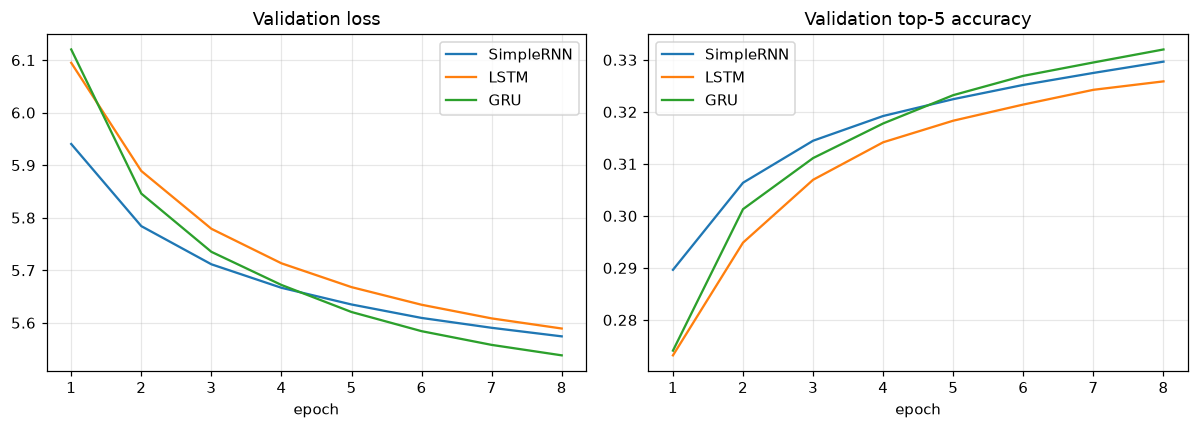

In [6]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for kind in [k for k in config.MODEL_KINDS if k in metrics]:
    h = json.loads((config.OUTPUTS_DIR / f"{kind}_history.json").read_text())
    axes[0].plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], label=labels[kind])
    axes[1].plot(range(1, len(h["val_top5_accuracy"]) + 1), h["val_top5_accuracy"], label=labels[kind])
axes[0].set(title="Validation loss", xlabel="epoch")
axes[1].set(title="Validation top-5 accuracy", xlabel="epoch")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "validation_curves_comparison.png", dpi=150)
plt.show()

## 6. Same prompts, three models

In [7]:
from src.predict import Predictor

prompts = ["i want to go to the ", "it is a ", "holmes was ", "what do you "]
predictors = {k: Predictor.load(config.MODELS_DIR / f"{k}.keras", config.VOCAB_PATH) for k in metrics}

rows = []
for p in prompts:
    row = {"prompt": p.strip()}
    for k, pr in predictors.items():
        row[labels[k]] = ", ".join(s["word"] for s in pr.predict_next(p, 5))
    rows.append(row)
pd.set_option("display.max_colwidth", 80)
pd.DataFrame(rows).set_index("prompt")

,LSTM,GRU,SimpleRNN
prompt,,,
i want to go to the,"first, new, same, world, way","world, same, next, end, house","same, end, first, world, next"
it is a,"good, lot, great, little, bit","good, great, lot, bit, little","good, bit, great, lot, little"
holmes was,"a, the, in, not, an","a, the, not, in, on","a, the, in, an, not"
what do you,"have, want, know, get, are","have, do, know, are, want","have, know, want, do, are"


## 7. Pick the production model

The deciding metric is **perplexity on the test set** (top-5 accuracy is what users feel). Training time and size break ties.

In [8]:
best = df["perplexity"].idxmin()
best_key = {v: k for k, v in labels.items()}[best]
print(f"Lowest perplexity: {best}  ->  set PRODUCTION_MODEL={best_key} (models/{best_key}.keras)")
print("Fastest to train  :", df["train_seconds"].idxmin())
print("Smallest          :", df["parameters"].idxmin())

Lowest perplexity: GRU  ->  set PRODUCTION_MODEL=gru (models/gru.keras)
Fastest to train  : LSTM
Smallest          : SimpleRNN


## 8. Conclusions

**GRU achieved the lowest perplexity at 253.01**, followed by SimpleRNN at 262.11 and LSTM at 265.92.

However, the GRU vs LSTM gap is **not clearly larger than run-to-run variation**. GRU ranked first in both runs, but the current setup of `seq_len=5`, 8 epochs, and ~977K samples is not enough to establish a decisive architectural advantage.

All three models have similar parameter counts of around **1.30M–1.32M**, mainly due to the embedding and output layers. Training time also varied across runs, indicating that CPU/system load can strongly affect timing.

**GRU is deployed** because it consistently achieved the lowest perplexity and remained competitive in training time. A larger experiment with longer sequences, more epochs, or multiple seeds would provide stronger evidence.

**Overall: GRU leads in this experiment, but the LSTM vs GRU difference remains inconclusive.**
